## Example 1:
Example workflow that loads a cropped z-stack from `examples` and reconstructs it by fitting the aberrations.

Fits the amplitude and phase of the aperture field, plus an ad hoc z-offset (which absorbs the
unknown offset between the nominal stack center and true best focus). An ad hoc z-scale parameter
is also included to absorb remaining index uncertainty or fudge factors with similar effects,
although it's expected to land near 1.

The fact that it doesn't here has been the cause of much weeping, crying, and gnashing of teeth,
Interestingly, it seems off by roughly the square of the axial scale, i.e., by (1.3744 / 1.0)^2,
and would go to 1 if one reversed the embedding and immersion media indices. Unfortunately, after
triple-checking my conventions, I see no physical justification for making that switch, and so
am leaving it as is. It may be that I'm misunderstanding the imaging system presented in the
source paper, and the reported z-stack distance is actually not an in-air shift.


In [1]:
from pathlib import Path

import numpy as np
import tifffile
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
import torch.optim as optim

In [2]:
from cynosure.beam_propagation.forward_zstack import ForwardZstack
from cynosure.config import ZernikeConfig
from cynosure.config_defaults import (
    get_default_simulation_config,
    get_default_optical_config,
)
from cynosure.object_distribution import FixedBead
from cynosure.utilities.image_utilities import blur_1d, laplacian_variance
from cynosure.utilities.visualization import plot_stack, plot_field

Helper function for loading an example z-stack, roughly centering it about the focal plane, and normalizing it to a reasonable range:

In [3]:
def load_example_image(image_path: str | Path, num_z: int, z_stride: int = 1) -> np.ndarray:
    stack = tifffile.imread(image_path)
    stack = stack[:, 1:, 1:]  # clumsy, patches are saved as 32x32, simulator wants (2^n - 1)x(2^n - 1)

    # Slice a smaller z-range around the focal plane
    lv = laplacian_variance(stack)
    lv = blur_1d(lv, sigma=2)
    z0 = np.argmax(lv)
    stack = stack[z0 - (num_z//2)*z_stride : z0 + (num_z//2)*z_stride + 1 : z_stride]

    # Roughly normalize
    stack = stack.astype(np.float64)
    stack = stack - stack.min((1, 2), keepdims=True)
    stack = stack / stack.sum((1, 2), keepdims=True)

    return stack

#### Setup

In [4]:
sim_cfg = get_default_simulation_config(object_pixel_size=0.08625)
opt_cfg = get_default_optical_config(
    numerical_aperture=0.95,
    medium_index=1.3744,  # Dako embedding for the beads
    immersion_index=1.0,  # air objective,
)
phase_cfg = ZernikeConfig(10)
amp_cfg = ZernikeConfig(6)

object_distrib = FixedBead(sim_cfg, bead_diameter=0.1)

In [5]:
rng_seed = 123
dz = 0.120  # um, physical objective z-step
num_z = 11  # number of z-slices to fit, ~centered around the focal plane
z_stride = 2  # data will be sampled to this multiple of `dz`
device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
image = load_example_image("../bead_patches/bead_patch_01.tiff", num_z, z_stride)
image = torch.from_numpy(image).to(device)

z_idx = torch.arange(-(num_z//2), num_z//2 + 1, dtype=torch.float64, device=device)
z_objective = z_idx * dz * z_stride  # physical objective/stage positions, as reported by the microscope

Viewing the raw images from the example before we start fitting:

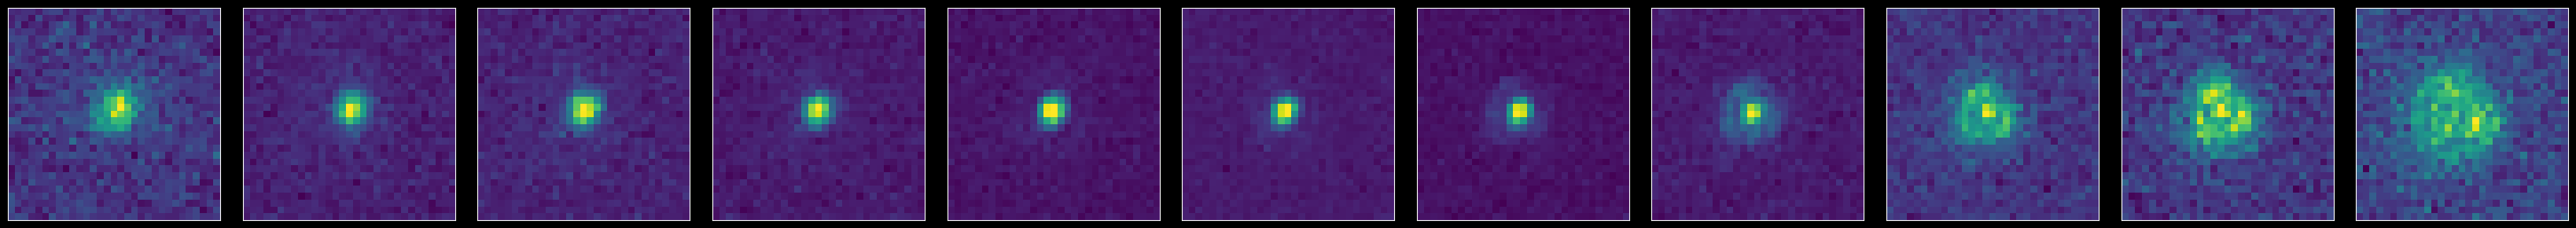

In [7]:
_ = plot_stack(image.numpy(force=True))

#### Fitting the z-stack

In [8]:
model = ForwardZstack(
    sim_cfg,
    opt_cfg,
    phase_cfg,
    z_objective,
    object_distrib,
    amp_cfg=amp_cfg,
    fit_zscale=True,
)
model = model.eval().to(device)

In [9]:
num_iters = 800
optimizer = optim.Adam(model.parameters(), lr=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_iters)

Fitting the forwards model via simple gradient descent:

In [10]:
pbar = tqdm(range(num_iters))
for iter in pbar:
    pred = model()
    loss = F.mse_loss(pred.sqrt(), image.sqrt())  # Poisson NLL would be better in principle, but this is similar for equalizing the variance

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    if iter > 0:
        # eats an extra D2H sync to do this every iter, but not a big deal for this small example
        pbar.set_postfix(loss=loss.item())

  0%|          | 0/800 [00:00<?, ?it/s]

#### Viewing the fit results

Text(406.94444444444446, 0.5, 'fitted')

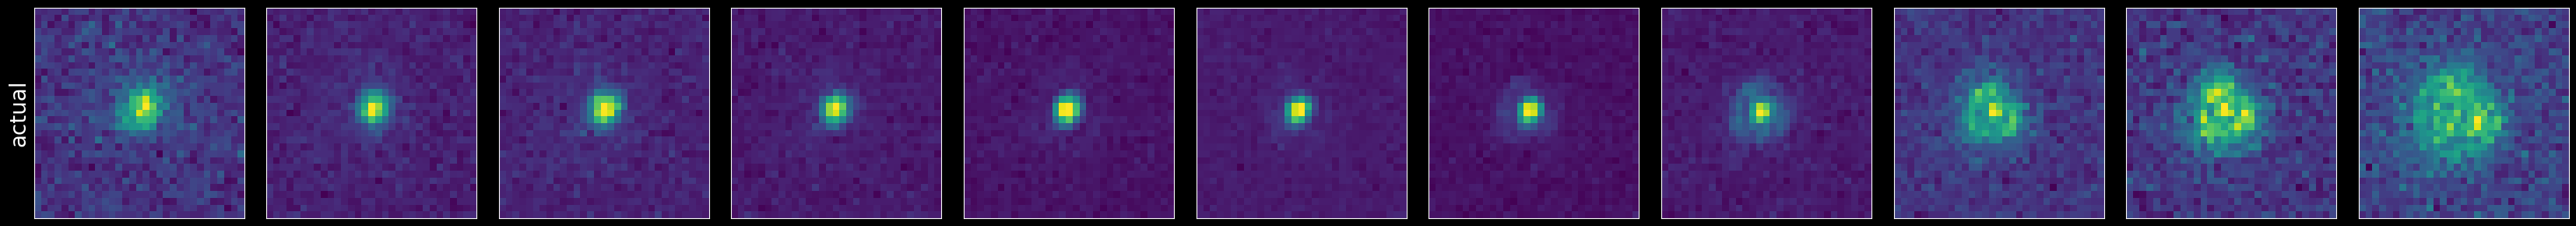

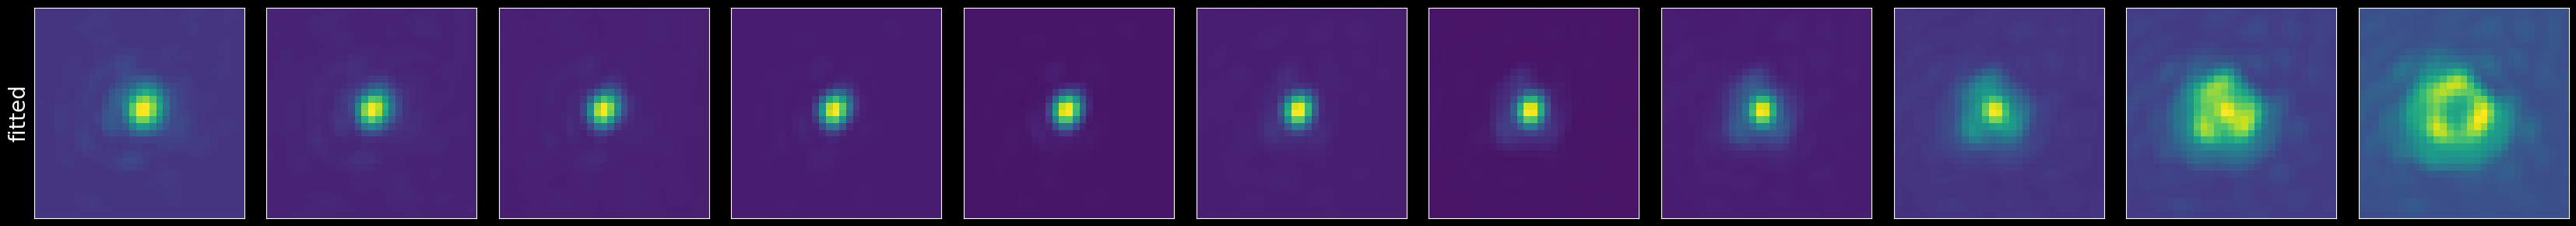

In [11]:
fig1 = plot_stack(image.numpy(force=True))
fig2 = plot_stack(pred.numpy(force=True))
fig1.axes[0].set_ylabel('actual', size=20)
fig2.axes[0].set_ylabel('fitted', size=20)

Just for fun, viewing the fitted phase and amplitude profiles:

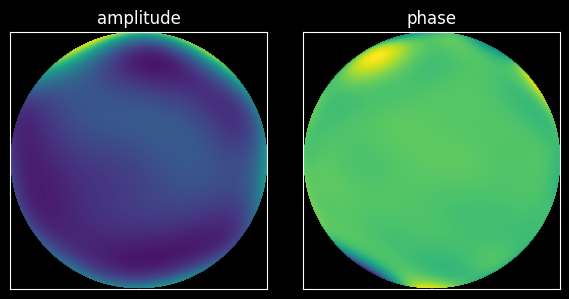

In [12]:
fig = plot_field(model.propagator, model.amp_coefs, model.phase_coefs)
fig.axes[0].get_images()[0].set_clim(vmin=0)

The fitted z-offset is ~0, showing that the crude, max-sharpness heuristic in `load_example_image` does reasonably well. The fitted axial scale, however, is far from 1; see the remarks at the top of this notebook for more information on that can of worms.

In [13]:
print(f"fitted z-scale: {model.z_scale:.3f}")
print(f"fitted z-offset: {model.z_offset:+.3f} um")

fitted z-scale: 0.511
fitted z-offset: +0.015 um
